`conda activate r_env_standr`

In [ ]:
suppressPackageStartupMessages({
    library(Seurat)
    library(dplyr)
    library(here)
    library(tibble)
    library(dittoSeq)
    library(stringr)
    library(data.table)
    library(tidyverse)
    library(patchwork) 
    library(RColorBrewer) 
    library(ggplot2)
    library(dplyr)
    library(magrittr)
    library(patchwork)
    library(Seurat)
    library(scCustomize)
    library(reticulate)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

### Braun2023 and Siletti predictions

#### Detailed annotations (Mossi et al.)

In [ ]:
braun2023 <- readRDS('/projects/0/einf2548/cruiz/dmg/data/predictions/malignant_rna_seurat_predictions_Braun2023_Siletti2023.rds')
braun2023

An object of class Seurat 
19289 features across 58339 samples within 2 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: prediction.score.siletti.DetailedCellClass
 2 dimensional reductions calculated: pca, umap

In [ ]:
nmf_assignment <- readRDS('nmf/data/nmf_assigment_malignant_no_core_programs.rds')
nmf_assignment

,MP_Assignment
,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,unresolved
BT042_PD_CTACCTGGTATGAAAC-1,MP_2_1
BT042_PD_TTGCATTTCCTGTAGA-1,MP_2_1
BT042_PD_GTGCTGGGTAACGCGA-1,MP_2_1
BT042_PD_CTTCTAAAGACGCATG-1,MP_2_1
BT042_PD_CCTCACACAAAGCTAA-1,MP_5_1
BT042_PD_ACAAGCTGTGGCTAGA-1,MP_5_1
BT042_PD_TTCCGGTAGGGAGTTC-1,MP_2_1
BT042_PD_ACAGAAAGTCTATGAC-1,MP_5_1


In [ ]:
braun2023 <- AddMetaData(braun2023, metadata = nmf_assignment)

In [ ]:
braun2023$NMF <- braun2023$MP_Assignment

In [ ]:
braun2023$NMF <- sub("_1$", "", braun2023$NMF)
braun2023$NMF <- factor(braun2023$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

In [ ]:
unique(braun2023$predicted.siletti.DetailedCellClass)

[1] "Neuron"                              "Astrocyte"                          
 [3] "Radial glia"                         "Pre-OPC"                            
 [5] "OPC"                                 "Pre-astrocyte"                      
 [7] "Oligodendrocyte"                     "Committed oligodendrocyte precursor"
 [9] "Oligodendrocyte precursor"           "Ependymal"                          
[11] "Vascular"                            "Microglia"                          
[13] "Miscellaneous"                       "Neuroblast"                         
[15] "Glioblast"

In [ ]:
braun2023$NMF <- factor(braun2023$NMF,
                       levels=c('MP_4','MP_11','MP_2','MP_5','MP_8','MP_3','MP_12','MP_7', 'MP_9', 'MP_13', 'unresolved'))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


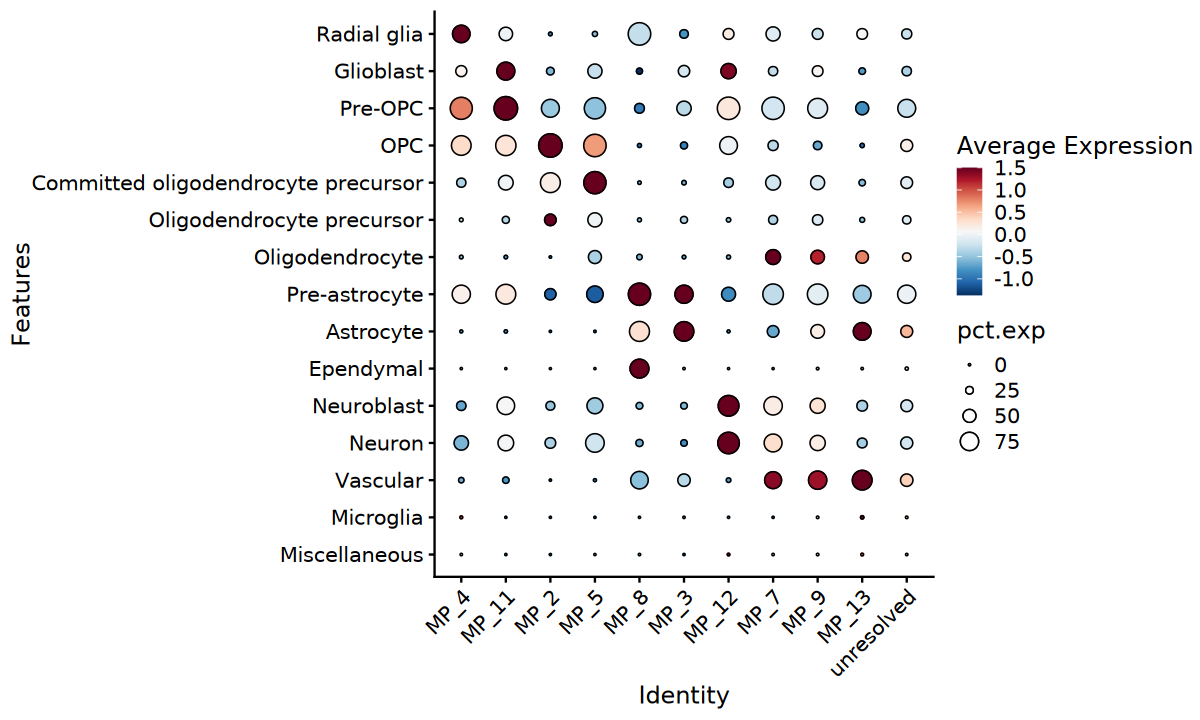

In [ ]:
options(repr.plot.height = 6, repr.plot.width = 10)
DotPlot(braun2023, features = rev(c('Radial glia','Glioblast',
                                    'Pre-OPC','OPC','Committed oligodendrocyte precursor','Oligodendrocyte precursor','Oligodendrocyte',
                                    'Pre-astrocyte','Astrocyte','Ependymal',
                                    'Neuroblast','Neuron',
                                    'Vascular','Microglia','Miscellaneous')), 
        group.by = 'NMF', assay = 'prediction.score.siletti.DetailedCellClass',
       col.min = -1.5, col.max= 1.5) +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

In [ ]:
ggsave('figures/braun2023_siletti_predicitons_dotplot_ordered.pdf', height = 5, width = 9)